# XGBoost Forecasting for ISPU (PM10 & PM2.5)

This notebook uses pre-engineered features from `../feature/final_feature.csv`.

In [249]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, classification_report
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('ggplot')

print("Setup complete.")

Setup complete.


In [250]:
# 2. Load Pre-Engineered Features
DATA_PATH = '../feature/final_feature.csv'

df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.set_index('tanggal')

print(f"Loaded: {df.shape}")
df.head()

Loaded: (15412, 58)


,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,target_kategori,...,quarter,month_feat,year_feat,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30
tanggal,,,,,,,,,,,,,,,,,,,,,
2010-01-01,DKI1,60.0,65.496864,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,...,1.0,1.0,2010.0,1.0,NaN,NaN,NaN,60.000000,NaN,60.000000
2010-01-02,DKI1,32.0,51.534592,2.0,16.0,33.0,9.0,33.0,O3,BAIK,...,1.0,1.0,2010.0,2.0,60.0,NaN,NaN,46.000000,19.798990,46.000000
2010-01-03,DKI1,27.0,43.427841,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,...,1.0,1.0,2010.0,3.0,32.0,NaN,NaN,39.666667,17.785762,39.666667
2010-01-04,DKI1,22.0,35.773327,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,...,1.0,1.0,2010.0,4.0,27.0,NaN,NaN,35.250000,16.997549,35.250000
2010-01-05,DKI1,25.0,37.706676,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,...,1.0,1.0,2010.0,5.0,22.0,NaN,NaN,33.200000,15.417522,33.200000


In [267]:
# 3. Smart Missing Value Handling
print(f"Original data shape: {df.shape}")
print(f"Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False).head(15)}")

# Only drop rows where target is missing
station_df = df[df['target_kategori'].notna()].copy()
print(f"\nAfter dropping rows with missing target: {station_df.shape}")

# Handle missing values in features
# 1. Forward fill for time series pollutant features (per station)
pollutant_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for col in pollutant_cols:
    if col in station_df.columns:
        station_df[col] = station_df.groupby('stasiun')[col].fillna(method='ffill').fillna(method='bfill')

# 2. Fill lag features with 0 (they're NaN at the start of each time series)
lag_cols = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']
for col in lag_cols:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna(0)

# 3. Fill weather columns with median
weather_cols = ['temperature_2m_min', 'temperature_2m_max', 'precipitation_hours', 
                'wind_speed_10m_max', 'wind_direction_10m_dominant', 'surface_pressure_min',
                'ventilation_proxy', 'relative_humidity_2m_mean', 'shortwave_radiation_sum',
                'cloud_cover_mean', 'surface_pressure_mean', 'wind_gusts_10m_max',
                'winddirection_10m_dominant', 'relative_humidity_2m_min']
for col in weather_cols:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna(station_df[col].median())

# 4. Fill categorical columns
# nama_libur: fill with 'Hari Kerja' (working day)
if 'nama_libur' in station_df.columns:
    station_df['nama_libur'] = station_df['nama_libur'].fillna('Hari Kerja')

# day_name: can be derived from tanggal if needed, or fill with mode
if 'day_name' in station_df.columns:
    station_df['day_name'] = station_df['day_name'].fillna(station_df['day_name'].mode()[0])

# critical_parameter: fill with most common value
if 'critical_parameter' in station_df.columns:
    station_df['critical_parameter'] = station_df['critical_parameter'].fillna(station_df['critical_parameter'].mode()[0])

# stasiun: this shouldn't be NaN, but if it is, forward fill
if 'stasiun' in station_df.columns and station_df['stasiun'].isnull().sum() > 0:
    station_df['stasiun'] = station_df['stasiun'].fillna(method='ffill')

# 5. Fill any remaining numeric columns with median
numeric_cols = station_df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if station_df[col].isnull().sum() > 0:
        station_df[col] = station_df[col].fillna(station_df[col].median())

# 6. Final check - report any remaining NaN
remaining_na = station_df.isnull().sum().sum()
if remaining_na > 0:
    print(f"\n⚠️ Warning: {remaining_na} NaN values remaining")
    print(station_df.isnull().sum()[station_df.isnull().sum() > 0])
    station_df = station_df.dropna()  # Drop only if really necessary
else:
    print(f"\n✅ No NaN values remaining!")

print(f"\n✅ Final data shape: {station_df.shape}")
print(f"   Data retention: {100*len(station_df)/len(df):.1f}%")
print(f"   Lost data: {len(df) - len(station_df)} rows")
print(f"   Stations: {sorted(station_df['stasiun'].unique())}")

Original data shape: (15412, 58)
Missing values per column:
nama_libur                     14706
temperature_2m_min               329
precipitation_hours              329
wind_speed_10m_max               329
wind_direction_10m_dominant      329
temperature_2m_max               329
surface_pressure_min             329
ventilation_proxy                329
relative_humidity_2m_mean        329
shortwave_radiation_sum          329
surface_pressure_mean            329
wind_gusts_10m_max               329
winddirection_10m_dominant       329
cloud_cover_mean                 329
relative_humidity_2m_min         329
dtype: int64

After dropping rows with missing target: (15412, 58)

✅ No NaN values remaining!

✅ Final data shape: (15412, 58)
   Data retention: 100.0%
   Lost data: 0 rows
   Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']


In [268]:
# 4. Prepare Train/Test Data
TARGET = 'target_kategori'

# Encode station as a categorical feature first
from sklearn.preprocessing import LabelEncoder
station_encoder = LabelEncoder()
station_df['stasiun_encoded'] = station_encoder.fit_transform(station_df['stasiun'])

# Use all relevant features from dataset (exclude target, non-numeric, and identifier columns)
# IMPORTANT: 'max' and 'critical_parameter' are DATA LEAKAGE - they are derived from the target!
exclude_cols = ['target_kategori', 'stasiun', 'max', 'critical_parameter', 'nama_libur', 'day_name', 
                'month', 'year', 'day_of_week', 'tahun']  # Exclude redundant temporal cols

FEATURES = [col for col in station_df.columns if col not in exclude_cols and station_df[col].dtype in ['int64', 'float64']]

print(f"Total features: {len(FEATURES)}")
print(f"Features: {FEATURES}")
print(f"Station mapping: {dict(zip(station_encoder.classes_, station_encoder.transform(station_encoder.classes_)))}")

# Map categories to 3 classes
def map_to_3_categories(cat):
    if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: 
        return 'TIDAK SEHAT'
    return cat

X = station_df[FEATURES]
y = station_df[TARGET].apply(map_to_3_categories)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Training samples: {len(X)}")
print(f"Target classes: {label_encoder.classes_}")

Total features: 49
Features: ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'cloud_cover_mean', 'surface_pressure_mean', 'wind_gusts_10m_max', 'winddirection_10m_dominant', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'cloud_cover_max', 'cloud_cover_min', 'wind_gusts_10m_mean', 'wind_speed_10m_mean', 'wind_gusts_10m_min', 'wind_speed_10m_min', 'surface_pressure_max', 'surface_pressure_min', 'washout_effect', 'ventilation_proxy', 'rainy_day', 'is_holiday_nasional', 'is_weekend', 'is_working_day', 'Total_Penduduk', 'ndvi', 'dayofweek', 'quarter', 'month_feat', 'year_feat', 'dayofyear', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'stasiun_encoded']
Station mapping: {'DKI1': np.int64(0), 'DKI2': np.int64(1), 'DKI3': np.int64(2), 

In [279]:
# 5. Model Training with Class Weights (Cross-Validation)
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
classes = np.unique(y_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(zip(classes, class_weights))

print(f"{'='*60}\nClass Distribution and Weights\n{'='*60}")
for i, cls in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    weight = class_weights[i]
    print(f"{cls:15s}: {count:3d} samples (weight: {weight:.3f})")

# Create sample weights array for all training data
sample_weights = np.array([class_weight_dict[y] for y in y_encoded])

tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

print(f"\n{'='*60}\nTraining with Balanced Class Weights\n{'='*60}")
scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    # Get sample weights for this fold
    train_weights = sample_weights[train_idx]
    val_weights = sample_weights[val_idx]
    
    model.fit(
        X_train, y_train,
        sample_weight=train_weights,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        sample_weight_eval_set=[train_weights, val_weights],
        verbose=False
    )
    
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average='macro')
    scores.append(f1)
    print(f"Fold {fold+1}: F1-Macro = {f1:.4f}")

print(f"\nAverage F1-Macro: {np.mean(scores):.4f}")
print(f"\nUsing final CV model trained with class weights.")

Class Distribution and Weights
BAIK           : 2342 samples (weight: 2.194)
SEDANG         : 10448 samples (weight: 0.492)
TIDAK SEHAT    : 2622 samples (weight: 1.959)

Training with Balanced Class Weights
Fold 1: F1-Macro = 0.8806
Fold 2: F1-Macro = 0.9875
Fold 3: F1-Macro = 0.9363
Fold 4: F1-Macro = 0.9686
Fold 5: F1-Macro = 0.9290

Average F1-Macro: 0.9404

Using final CV model trained with class weights.


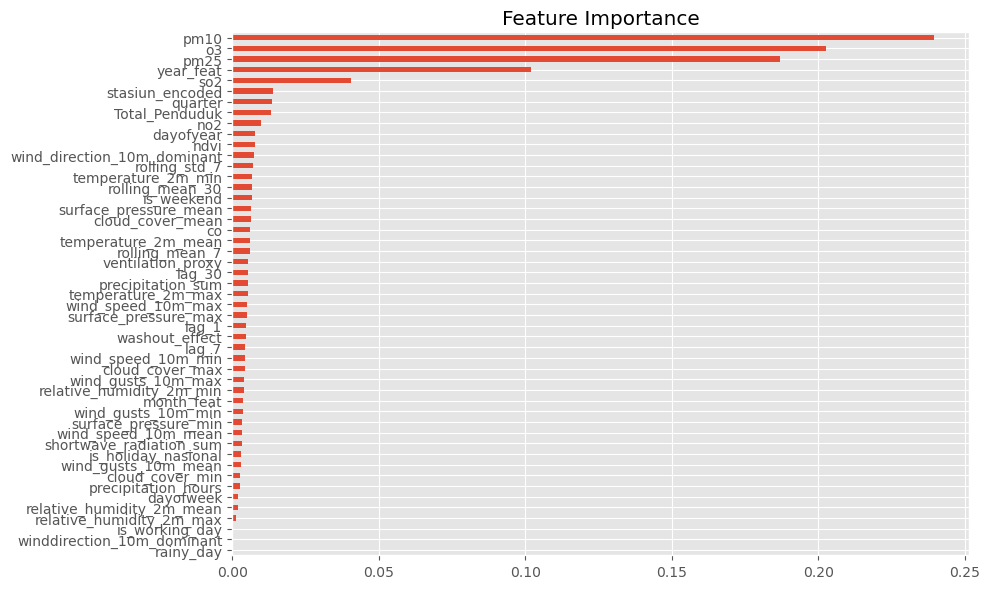

In [280]:
# 7. Feature Importance
plt.figure(figsize=(10, 6))
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importance.plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [276]:
# 8. Sample Prediction
sample_pred = model.predict(X.tail(10))
print("Last 10 Predictions:")
print(sample_pred)

Last 10 Predictions:
[2 2 2 2 2 2 2 1 1 1]


In [277]:

# 9. Generate Submission for Sep-Nov 2025 (Pure XGBoost - Category Only)
submission_start = pd.Timestamp('2025-09-01')
submission_end = pd.Timestamp('2025-11-30')
submission_date_range = pd.date_range(start=submission_start, end=submission_end, freq='D')
stations = sorted([s for s in df['stasiun'].unique() if pd.notna(s)])

print(f"{'='*60}\nGenerating Pure XGBoost Category Predictions\n{'='*60}")
print(f"Period: {submission_start.date()} to {submission_end.date()}\nTotal days: {len(submission_date_range)}\nStations: {stations}")

submission_records = []

# Use trained model to predict for each station
for station in stations:
    print(f"\n📊 Processing {station}...")
    station_hist = df[df['stasiun'] == station].copy()
    
    if len(station_hist) == 0:
        print(f"  ⚠️ No data for {station}, skipping...")
        continue
    
    station_encoded_val = station_encoder.transform([station])[0]
    
    # Start from last known state (no lag updates)
    feature_cols = [f for f in FEATURES if f != 'stasiun_encoded']
    last_features = station_hist.iloc[-1:][feature_cols].copy()
    last_features['stasiun_encoded'] = station_encoded_val
    
    # Track predictions for this station
    station_predictions = []
    
    # Generate predictions for each date
    for date in submission_date_range:
        # Create feature vector from last state
        pred_features = last_features.copy()
        
        # Update only temporal features for current date
        pred_features['dayofweek'] = date.dayofweek
        pred_features['month_feat'] = date.month
        pred_features['year_feat'] = date.year
        pred_features['dayofyear'] = date.dayofyear
        pred_features['quarter'] = date.quarter
        
        # Predict category using XGBoost
        pred_encoded = model.predict(pred_features[FEATURES].fillna(0))[0]
        pred_category = label_encoder.inverse_transform([pred_encoded])[0]
        
        # Store prediction
        submission_records.append({'id': f"{date.strftime('%Y-%m-%d')}_{station}", 'category': pred_category})
        station_predictions.append(pred_category)
    
    # Print category distribution for this station
    from collections import Counter
    pred_counts = Counter(station_predictions)
    print(f"  Predictions: {dict(pred_counts)}")
    print(f"  ✓ Generated {len(submission_date_range)} predictions")

submission_df = pd.DataFrame(submission_records)
print(f"\n{'='*60}")
print(f"Submission shape: {submission_df.shape}\nExpected shape: (455, 2)")
print(f"\nCategory distribution:\n{submission_df['category'].value_counts()}")

Generating Pure XGBoost Category Predictions
Period: 2025-09-01 to 2025-11-30
Total days: 91
Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

📊 Processing DKI1...
  Predictions: {'SEDANG': 91}
  ✓ Generated 91 predictions

📊 Processing DKI2...
  Predictions: {'TIDAK SEHAT': 91}
  ✓ Generated 91 predictions

📊 Processing DKI3...
  Predictions: {'TIDAK SEHAT': 91}
  ✓ Generated 91 predictions

📊 Processing DKI4...
  Predictions: {'TIDAK SEHAT': 91}
  ✓ Generated 91 predictions

📊 Processing DKI5...
  Predictions: {'TIDAK SEHAT': 91}
  ✓ Generated 91 predictions

Submission shape: (455, 2)
Expected shape: (455, 2)

Category distribution:
category
TIDAK SEHAT    364
SEDANG          91
Name: count, dtype: int64


Submission saved: predictions_xgb.csv

FINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)
Matched predictions: 455 / 455

🎯 F1-Score (Macro):    0.1363
🎯 F1-Score (Weighted): 0.2728

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        63
      SEDANG       0.84      0.21      0.33       368
 TIDAK SEHAT       0.04      0.68      0.08        22

   micro avg       0.20      0.20      0.20       453
   macro avg       0.29      0.30      0.14       453
weighted avg       0.68      0.20      0.27       453



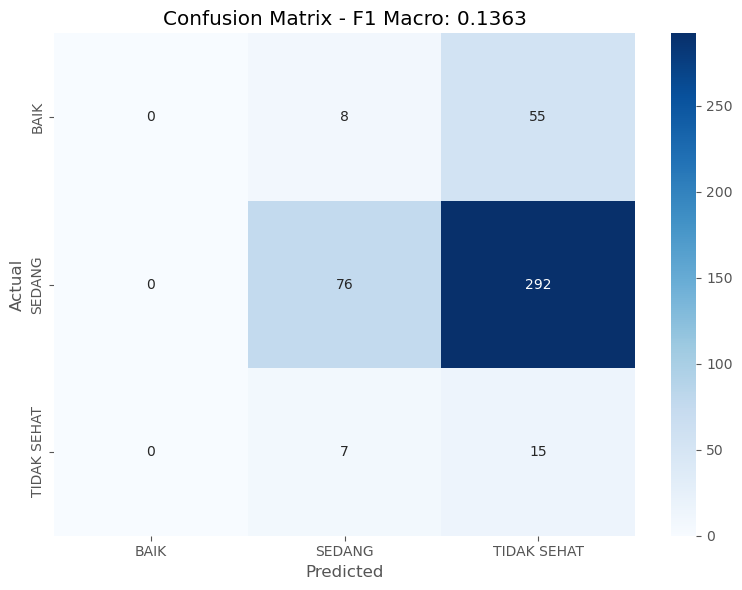

In [281]:
# 10. Evaluation vs Ground Truth
submission_df.to_csv('predictions_xgb.csv', index=False)
print(f"Submission saved: predictions_xgb.csv")

try:
    gt = pd.read_csv('../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv')
except:
    gt = None

if gt is not None:
    from sklearn.metrics import f1_score, classification_report, confusion_matrix
    import seaborn as sns
    
    # Parse date from periode_data (YYYYMM format) + tanggal (day)
    gt['year'] = gt['periode_data'] // 100
    gt['month'] = gt['periode_data'] % 100
    gt['day'] = gt['tanggal']
    gt['tanggal'] = pd.to_datetime(gt[['year', 'month', 'day']], errors='coerce')
    
    # Map station names and use pm_sepuluh column
    station_map = {'DKI1 Bunderan HI': 'DKI1', 'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1', 'DKI1 Bundaran Hotel Indonesia HI': 'DKI1', 'DKI2 Kelapa Gading': 'DKI2', 'DKI3 Jagakarsa': 'DKI3', 'DKI4 Lubang Buaya': 'DKI4', 'DKI5 Kebon Jeruk': 'DKI5', 'DKI5 Kebon Jeruk Jakarta Barat': 'DKI5'}
    gt['stasiun'] = gt['stasiun'].map(station_map).fillna(gt['stasiun'])
    gt_2025 = gt[(gt['tanggal'] >= '2025-09-01') & (gt['tanggal'] <= '2025-11-30')].copy()
    gt_2025['id'] = gt_2025['tanggal'].dt.strftime('%Y-%m-%d') + '_' + gt_2025['stasiun']
    
    def map_to_3_categories(cat):
        if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: return 'TIDAK SEHAT'
        return cat
    
    col_name = 'target_kategori' if 'target_kategori' in gt_2025.columns else 'kategori'
    gt_2025['kategori_mapped'] = gt_2025[col_name].apply(map_to_3_categories)
    merged = submission_df.merge(gt_2025[['id', 'kategori_mapped']], on='id', how='left')
    merged = merged.dropna(subset=['kategori_mapped'])
    
    if len(merged) > 0:
        y_true, y_pred = merged['kategori_mapped'].values, merged['category'].values
        f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        
        print(f"\n{'='*70}\nFINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)\n{'='*70}")
        print(f"Matched predictions: {len(merged)} / {len(submission_df)}\n\n🎯 F1-Score (Macro):    {f1_macro:.4f}")
        print(f"🎯 F1-Score (Weighted): {f1_weighted:.4f}")
        print(f"\n{'='*70}\nClassification Report:\n{'='*70}")
        print(classification_report(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], target_names=['BAIK', 'SEDANG', 'TIDAK SEHAT'], zero_division=0))
        
        conf_matrix = confusion_matrix(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], yticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.title(f'Confusion Matrix - F1 Macro: {f1_macro:.4f}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No matching records found")
else:
    print("ℹ️ Ground truth file not available")